# OS Analysis

**This notebook analyzes overall survival in patients with advanced urothelial cancer treated with first-line pembrolizumab or carboplatin-based chemotherapy.** 

In [1]:
import numpy as np
import pandas as pd

from iptw_survival import IPTWSurvivalEstimator

import matplotlib.pyplot as plt
from lifelines.plotting import add_at_risk_counts

## Import data

In [2]:
treatment_df = pd.read_csv('../outputs/pembro_carbo_index.csv')

In [3]:
treatment_df.sample(3)

,PatientID,LineName,StartDate,avelumab_maintenance
532,F24001A7EB2DB,pembro,2019-08-28,0
675,FF98DE288D1F3,pembro,2021-12-28,0
893,FEA264ADCBABC,pembro,2020-01-28,0


In [4]:
treatment_df.shape

(3712, 4)

In [5]:
treatment_df['treatment'] = (treatment_df['LineName'] == 'carbo').astype(int)

In [6]:
dtype_map = pd.read_csv('../outputs/pembro_carbo_features_dtypes.csv', index_col = 0).iloc[:, 0].to_dict()
features_df = pd.read_csv('../outputs/pembro_carbo_features_df.csv', dtype = dtype_map)

In [7]:
features_df.head(3)

,PatientID,DiseaseGrade,SmokingStatus,GroupStage_mod,TStage_mod,NStage_mod,MStage_mod,Surgery_mod,SurgeryType_mod,days_diagnosis_to_adv,...,other_gi_met,other_combined_met,event,duration,commercial,medicaid,medicare,other_insurance,ses_mod,ses_mod_na
0,F5AAF96C85477,High grade (G2/G3/G4),History of smoking,4.0,other,unknown,unknown,0,unknown,109.0,...,0,0,0,68.0,0,0,1,0,1.0,0
1,F788831A66E9A,High grade (G2/G3/G4),History of smoking,4.0,T1,unknown,M0,1,bladder,2411.0,...,0,0,0,78.0,1,0,1,0,1.0,0
2,FAF26C1A1CEE4,High grade (G2/G3/G4),History of smoking,4.0,T1,unknown,M0,1,bladder,1165.0,...,0,0,0,7.0,1,0,0,0,5.0,0


In [8]:
features_df.shape

(3706, 162)

In [9]:
df = pd.merge(features_df, treatment_df, on = 'PatientID', how = 'left')

In [10]:
df.shape

(3706, 166)

In [11]:
df = df.query('adv_diagnosis_year <= 2021')

In [12]:
df.shape

(3138, 166)

## Survival analysis with IPTW

In [13]:
df.treatment.value_counts()

treatment
1    1972
0    1166
Name: count, dtype: int64

In [14]:
# Percent censored
(
    df.groupby('treatment')['event']
    .apply(lambda x: (x == 0).mean())
)

treatment
0    0.285592
1    0.212982
Name: event, dtype: float64

In [15]:
estimator = IPTWSurvivalEstimator()

In [16]:
estimator.fit(df = df,
              treatment_col = 'treatment',
              cat_var = ['SmokingStatus', 'PDL1_status'],
              cont_var = ['days_diagnosis_to_adv', 'GroupStage_mod', 'ecog_index', 'ses_mod', 'age', 'weight_index', 'percent_change_weight', 'albumin', 'total_bilirubin', 'creatinine', 'van_walraven_score'],
              binary_var = ['sex_male', 'medicaid', 'before_2020', 'days_to_treatment_before_30d', 'GroupStage_mod_na', 'ecog_index_na', 'ses_mod_na', 'Surgery_mod', 'PrimarySite_lower'],
              lr_kwargs = {
                  'class_weight': 'balanced',
                  'solver': 'lbfgs',
                  'penalty': 'l2',
                  'max_iter': 1000,
                  'random_state': 42
              },
              clip_bounds = (0.01, 0.99),
              stabilized = True,
              use_missing_flags = False)

In [17]:
iptw_df = estimator.transform()

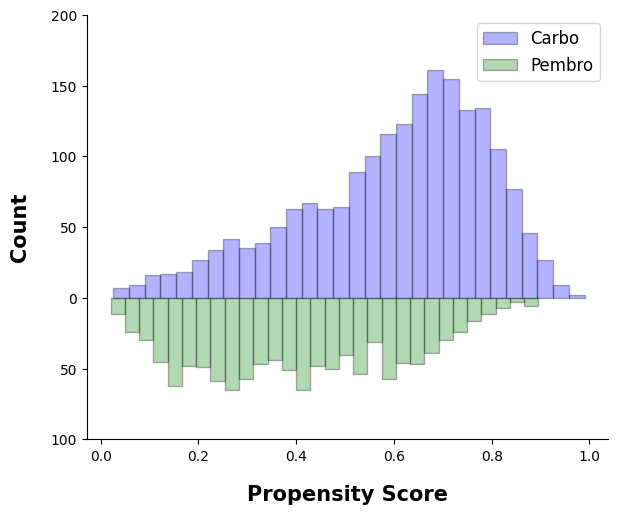

In [18]:
ps_fig = estimator.propensity_score_plot(bins = 30)

ax = ps_fig.axes[0]

ax.set_xlabel('Propensity Score', fontsize = 15)
ax.set_ylabel('Count', fontsize = 15)
ax.set_title('')
ps_fig.set_size_inches(6, 6)

handles, labels = ax.get_legend_handles_labels()
label_map = {'Treatment': 'Carbo', 'Control': 'Pembro'}
ax.legend(handles, [label_map.get(l, l) for l in labels], prop={'size': 12})

ps_fig.savefig('../outputs/ps_plot.pdf', dpi=300, bbox_inches='tight')
ps_fig

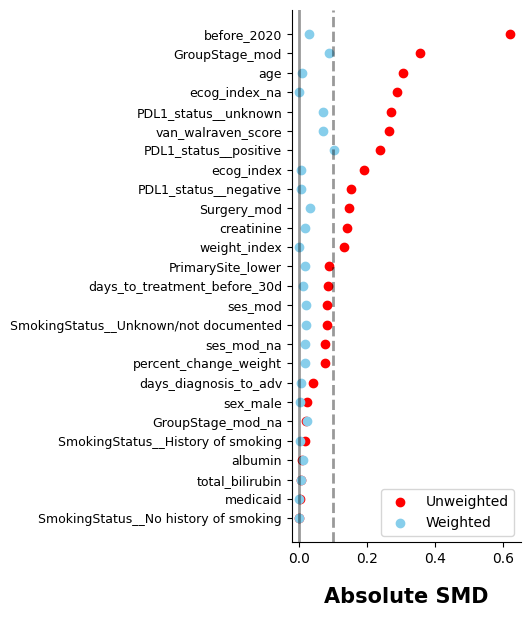

In [19]:
_, smd_fig = estimator.standardized_mean_differences(return_fig = True)

ax = smd_fig.axes[0]

# Resize figure
smd_fig.set_size_inches(4, 6)

# Axis/title font sizes
ax.set_xlabel('Absolute SMD', fontsize=15)
ax.set_title('')

# Reference line styles
for line in ax.lines:
    line.set_alpha(0.4)

ax.tick_params(axis='y', labelsize=9)
ax.legend(prop={'size': 10})
smd_fig.savefig('../outputs/smd_plot_os.pdf', dpi=300, bbox_inches='tight')
smd_fig

In [20]:
km_confidence_intervals_df = estimator.km_confidence_intervals(df = iptw_df,
                                                               duration_col = 'duration',
                                                               event_col = 'event',
                                                               weight_col = 'iptw',
                                                               n_bootstrap = 1000,
                                                               random_state = 42,
                                                               n_jobs = -1)

In [21]:
results = estimator.survival_metrics(df = iptw_df,
                                     duration_col = 'duration',
                                     event_col = 'event',
                                     weight_col = 'iptw',
                                     psurv_time_points = [730, 1095, 1460],
                                     rmst_time_points = [730, 1095, 1460],
                                     median_time = True,
                                     n_bootstrap = 1000,
                                     random_state = 42,
                                     n_jobs = -1)

In [22]:
print('Median survival results')
print(f'Carboplatin: {tuple(round(x / 30, 1) for x in results['treatment']['median'])} months')
print(f'Pembrolizumab: {tuple(round(x / 30, 1) for x in results['control']['median'])} months')
print(f'Difference: {tuple(round(x / 30, 1) for x in results['difference']['median'])} months')

Median survival results
Carboplatin: (11.7, 10.6, 12.8) months
Pembrolizumab: (9.6, 8.2, 11.7) months
Difference: (2.1, -0.2, 3.8) months


In [23]:
print('RMST results at 2 years')
print(f'Carboplatin: {tuple(round(x, 1) for x in results['treatment']['rmst'][730])} days')
print(f'Pembrolizumab: {tuple(round(x, 1) for x in results['control']['rmst'][730])} days')
print(f'Difference: {tuple(round(x, 1) for x in results['difference']['rmst'][730])} days')

print('')
print('RMST results at 3 years')
print(f'Carboplatin: {tuple(round(x, 1) for x in results['treatment']['rmst'][1095])} days')
print(f'Pembrolizumab: {tuple(round(x, 1) for x in results['control']['rmst'][1095])} days')
print(f'Difference: {tuple(round(x, 1) for x in results['difference']['rmst'][1095])} days')

print('')
print('RMST results at 4 years')
print(f'Carboplatin: {tuple(round(x, 1) for x in results['treatment']['rmst'][1460])} days')
print(f'Pembrolizumab: {tuple(round(x, 1) for x in results['control']['rmst'][1460])} days')
print(f'Difference: {tuple(round(x, 1) for x in results['difference']['rmst'][1460])} days')

RMST results at 2 years
Carboplatin: (401.4, 386.0, 416.1) days
Pembrolizumab: (374.1, 356.1, 393.6) days
Difference: (27.3, 4.5, 49.8) days

RMST results at 3 years
Carboplatin: (485.1, 463.1, 507.4) days
Pembrolizumab: (477.9, 450.8, 507.9) days
Difference: (7.2, -26.3, 40.8) days

RMST results at 4 years
Carboplatin: (548.7, 518.0, 576.9) days
Pembrolizumab: (558.8, 524.0, 598.8) days
Difference: (-10.2, -55.5, 35.1) days


In [24]:
print('Probability of survival at 2 years')
print(f'Carboplatin: {tuple(round(x, 3) for x in results['treatment']['survival_prob'][730])}')
print(f'Pembrolizumab: {tuple(round(x, 3) for x in results['control']['survival_prob'][730])}')
print(f'Difference: {tuple(round(x, 3) for x in results['difference']['survival_prob'][730])}')

print('')
print('Probability of survival at 3 years')
print(f'Carboplatin: {tuple(round(x, 3) for x in results['treatment']['survival_prob'][1095])}')
print(f'Pembrolizumab: {tuple(round(x, 3) for x in results['control']['survival_prob'][1095])}')
print(f'Difference: {tuple(round(x, 3) for x in results['difference']['survival_prob'][1095])}')

print('')
print('Probability of survival at 4 years')
print(f'Carboplatin: {tuple(round(x, 3) for x in results['treatment']['survival_prob'][1460])}')
print(f'Pembrolizumab: {tuple(round(x, 3) for x in results['control']['survival_prob'][1460])}')
print(f'Difference: {tuple(round(x, 3) for x in results['difference']['survival_prob'][1460])}')

Probability of survival at 2 years
Carboplatin: (0.275, 0.248, 0.301)
Pembrolizumab: (0.323, 0.292, 0.357)
Difference: (-0.049, -0.091, -0.009)

Probability of survival at 3 years
Carboplatin: (0.194, 0.169, 0.218)
Pembrolizumab: (0.243, 0.213, 0.274)
Difference: (-0.049, -0.088, -0.013)

Probability of survival at 4 years
Carboplatin: (0.158, 0.133, 0.179)
Pembrolizumab: (0.21, 0.178, 0.243)
Difference: (-0.052, -0.09, -0.016)


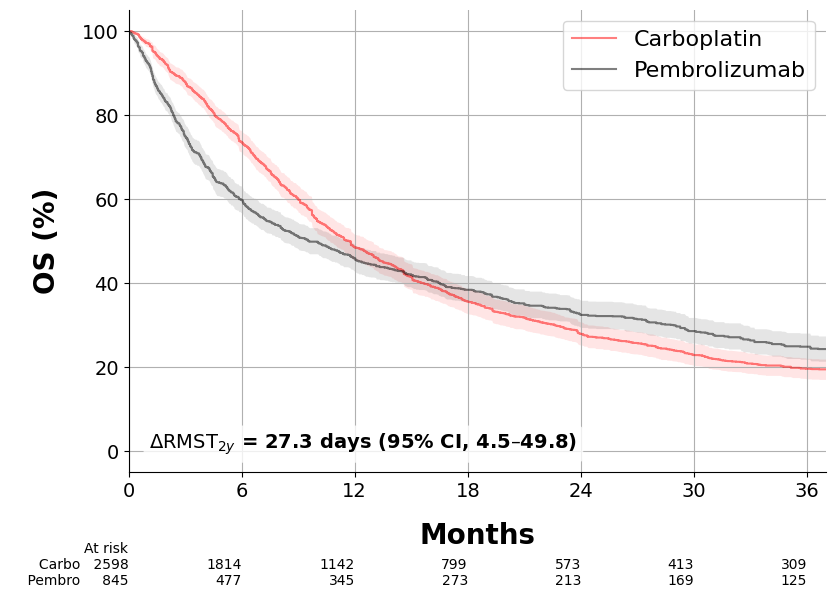

In [25]:
fig = plt.figure(figsize=(9, 6))
ax = plt.gca()

# pembro + chemo estimate
ax.step(km_confidence_intervals_df.time, 
        km_confidence_intervals_df.treatment_estimate * 100, 
        color='red', 
        alpha=0.5,
        label='Carboplatin')

# 95% CI
ax.fill_between(km_confidence_intervals_df.time, 
                km_confidence_intervals_df.treatment_lower_ci * 100, 
                km_confidence_intervals_df.treatment_upper_ci * 100, 
                facecolor='red', 
                alpha=0.1)

# pembro estimate
ax.step(km_confidence_intervals_df.time, 
        km_confidence_intervals_df.control_estimate * 100, 
        color='black', 
        alpha=0.5,
        label='Pembrolizumab')

# 95% CI
ax.fill_between(km_confidence_intervals_df.time, 
                km_confidence_intervals_df.control_lower_ci * 100, 
                km_confidence_intervals_df.control_upper_ci * 100, 
                facecolor='black', 
                alpha=0.1)

tick_months = np.arange(0, 37, 6)   
tick_days = tick_months * 30  
ax.set_xticks(tick_days, labels=[str(m) for m in tick_months])
ax.set_xlim(0, 37 * 30)

ax.set_ylabel('OS (%)', size=20, weight='bold', labelpad=15)
ax.set_xlabel('Months', size=20, weight='bold', labelpad=15)
ax.tick_params(axis='both', labelsize=14)
ax.legend(prop={'size': 16})
ax.grid(True)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# RMST difference at 2 years
rmst_diff, rmst_lower, rmst_upper = results['difference']['rmst'][730]

rmst_text = (
    r'$\Delta \mathrm{RMST}_{2y}$ = '
    f'{rmst_diff:.1f} days '
    f'(95% CI, {rmst_lower:.1f}–{rmst_upper:.1f})'
)

add_at_risk_counts(
    estimator.treat_km_, 
    estimator.control_km_, 
    rows_to_show=['At risk'], 
    labels=['Carbo', 'Pembro'],
    xticks=tick_days
)

ax.text(
    0.03, 0.05, rmst_text,
    transform=ax.transAxes,
    fontsize=14,
    fontweight='bold',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='none')
)

plt.savefig('../outputs/os_pembro_carbo.pdf', format='pdf', bbox_inches='tight')